# Example-33: Birkhoff average frequency estimation

In [1]:
# In this example frequency estimation technique based on Birkhoff average is illustrated

# G. Russo, M. Giovannozzi and G. Franchetti, NEW TECHNIQUES TO COMPUTE THE LINEAR TUNE
# https://accelconf.web.cern.ch/ipac2021/doi/JACoW-IPAC2021-THPAB189.html

# Birkhoff average also works with instantaneous frequency from DHT, which is cool, since real input signal can be used

# First, the method is applied to a single component signal and compared with Candan and parabola estimators
# Next, methods are compared using simple symplectic mapping
# Finaly, the performance with noise is tested

In [2]:
# Import

import numpy
import torch

import sys
sys.path.append('..')

from math import pi

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)

In [3]:
# Set analytical filter
# Note, only default order will be used

def birkhoff(length, order=1.0):
    t = torch.linspace(0.0, (length - 1.0)/length, length, dtype=torch.float64)
    w = (-1/((1 - t)**order*t**order)).exp()
    return w

In [4]:
# Estimate frequency for a single component complex signal using Candan and parabola estimators

# Set signal

c = 512
w = Window.from_cosine(c, 1.0, dtype=torch.float64)
q = torch.cos(2.0*numpy.pi*0.12*torch.linspace(1, c, c, dtype=torch.complex128))
p = torch.sin(2.0*numpy.pi*0.12*torch.linspace(1, c, c, dtype=torch.complex128))
z = q + 1j*p

# Estimate frequency

t = Data.from_data(w, torch.stack([z]))
f = Frequency(t, f_range=(0.0, 1.0))
t.window_apply()
f('parabola')
t.reset()

# Result

print(abs(0.12 - f.candan_get_frequency().item()))
print(abs(0.12 - f.frequency.item()))
print()

# Estimate frequency using Birkhoff avarage of phase advance, compare with mean phase advance

advance = mod(z.angle().diff(), 2*pi)/(2*pi)
window = birkhoff(len(advance))

print(abs(0.12 - advance.mean().item()))
print(abs(0.12 - (advance @ window/window.sum()).item()))
print()

1.3877787807814457e-17
5.2203796840899486e-12

1.3877787807814457e-17
0.0



In [5]:
# Estimate frequency for a single component complex signal using Candan and parabola estimators with noise

# Set signal with noise

n = 0.05
c = 512
w = Window.from_cosine(c, 1.0, dtype=torch.float64)
q = torch.cos(2.0*numpy.pi*0.12*torch.linspace(1, c, c, dtype=torch.complex128))
p = torch.sin(2.0*numpy.pi*0.12*torch.linspace(1, c, c, dtype=torch.complex128))
q += n*torch.randn_like(q)
p += n*torch.randn_like(p)
z = q + 1j*p

# Estimate frequency

t = Data.from_data(w, torch.stack([z]))
f = Frequency(t, f_range=(0.0, 1.0))
t.window_apply()
f('parabola')
t.reset()

# Result

print(abs(0.12 - f.candan_get_frequency().item()))
print(abs(0.12 - f.frequency.item()))
print()

# Estimate frequency using Birkhoff avarage of phase advance, compare with mean phase advance

advance = mod(z.angle().diff(), 2*pi)/(2*pi)
window = birkhoff(len(advance))

print(abs(0.12 - advance.mean().item()))
print(abs(0.12 - (advance @ window/window.sum()).item()))
print()

2.923048341763046e-06
3.0112635548973365e-07

2.8367784111194005e-06
1.2767115073475388e-08



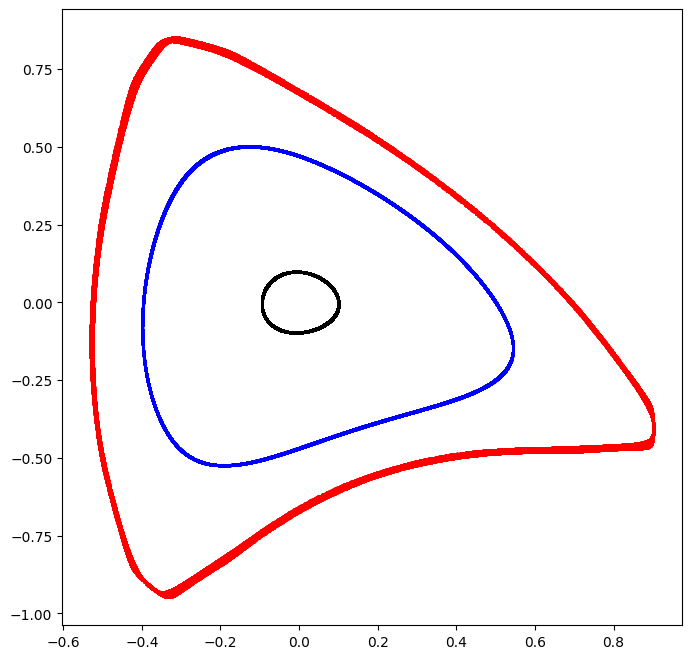

In [6]:
# Set test nonlinear mapping and generate several orbits

dtype = torch.float64
device = torch.device('cpu')

a1, b1 = 0, 1
a2, b2 = 0, 1

f1 = torch.tensor(2.0*numpy.pi*0.38, dtype=dtype, device=device)
f2 = torch.tensor(2.0*numpy.pi*0.41, dtype=dtype, device=device)

cf1, sf1 = f1.cos(), f1.sin()
cf2, sf2 = f2.cos(), f2.sin()

def mapping(x, k):
    q1, p1, q2, p2 = x
    k, = k
    return torch.stack([
        b1*(p1 + k*(q1**2 - q2**2))*sf1 + q1*(cf1 + a1*sf1),
        -((q1*(1 + a1**2)*sf1)/b1) + (p1 + k*(q1**2 - q2**2))*(cf1 - a1*sf1),
        q2*cf2 + (p2*b2 + k*q2*(a2 - 2*q1*b2))*sf2,
        -((q2*(1 + a2**2)*sf2)/b2) + (p2 - 2*k*q1*q2)*(cf2 - a2*sf2)
    ])


count = 2**16

plt.figure(figsize=(8, 8))

k = torch.tensor([1.0], dtype=dtype)

x = torch.tensor([0.10000, 0.0, 0.05, 0.0], dtype=dtype)
orbit = []
for _ in range(count):
    x = mapping(x, k)
    orbit.append(x)
q, p, *_ = torch.stack(orbit).T
qa = torch.clone(q)
pa = torch.clone(p)
za = qa - 1j*pa
plt.scatter(q, p, s =1, color='black')

x = torch.tensor([0.50000, 0.0, 0.05, 0.0], dtype=dtype)
orbit = []
for _ in range(count):
    x = mapping(x, k)
    orbit.append(x)
q, p, *_ = torch.stack(orbit).T
qb = torch.clone(q)
pb = torch.clone(p)
zb = qb - 1j*pb
plt.scatter(q, p, s =1, color='blue')

x = torch.tensor([0.68925, 0.0, 0.10, 0.0], dtype=dtype)
orbit = []
for _ in range(count):
    x = mapping(x, k)
    orbit.append(x)
q, p, *_ = torch.stack(orbit).T
qc = torch.clone(q)
pc = torch.clone(p)
zc = qc - 1j*pc
plt.scatter(q, p, s =1, color='red')

plt.show()

In [7]:
# Estimate frequencies using full length and high order window

c = 2**16

w = Window.from_cosine(c, 4.0, dtype=torch.float64)
t = Data.from_data(w, torch.stack([za, zb, zc])[:, :c])
f = Frequency(t, f_range=(0.0, 1.0))
t.window_apply()
f('parabola')
t.reset()

out = f.frequency.clone()

print(out.cpu().numpy())

[0.37964238 0.37214998 0.35817635]


In [8]:
# Estimate frequencies

# Note, Candan estimator needs isolated peak, it perfoms OK given a large sample
# Estimation with parabola perfoms better with high order window, since spectral leakage introduces bias, but the optimal order is not straightforward

c = 1024

w = Window.from_cosine(c, 1.0, dtype=torch.float64)
t = Data.from_data(w, torch.stack([za, zb, zc])[:, :c])
f = Frequency(t, f_range=(0.0, 1.0))

t.window_apply()
f('parabola')
t.reset()

print((out - f.candan_get_frequency()).abs().cpu().numpy())
print((out - f.frequency).abs().cpu().numpy())
print()

advance = mod(t.data.angle().diff(), 2*pi)/(2*pi)
window = birkhoff(c - 1)

print((out - advance.mean(1)).abs().cpu().numpy())
print((out - (advance @ window)/window.sum()).abs().cpu().numpy())
print()

[1.34361189e-10 1.16096026e-08 2.71826332e-06]
[1.43568490e-12 5.85099232e-08 1.89529893e-06]

[2.59038131e-06 3.82220735e-05 1.18837108e-05]
[1.16462395e-13 1.62407112e-07 3.29174394e-07]



In [9]:
# Test instantaneous frequency (Hilbert) with Birkhoff averaging

dht = f.dht(torch.stack([qa, qb, qc])[:, :c])
dht = 1/(2.0*pi)*(dht[:, :-1]*dht[:, 1:].conj()).angle()

print((out - dht.mean(1)).abs().cpu().numpy())
print((out - (dht @ window)/window.sum()).abs().cpu().numpy())
print()

[7.97958370e-05 3.59492010e-05 1.85312092e-04]
[3.22564198e-12 1.63536553e-07 3.16859796e-07]



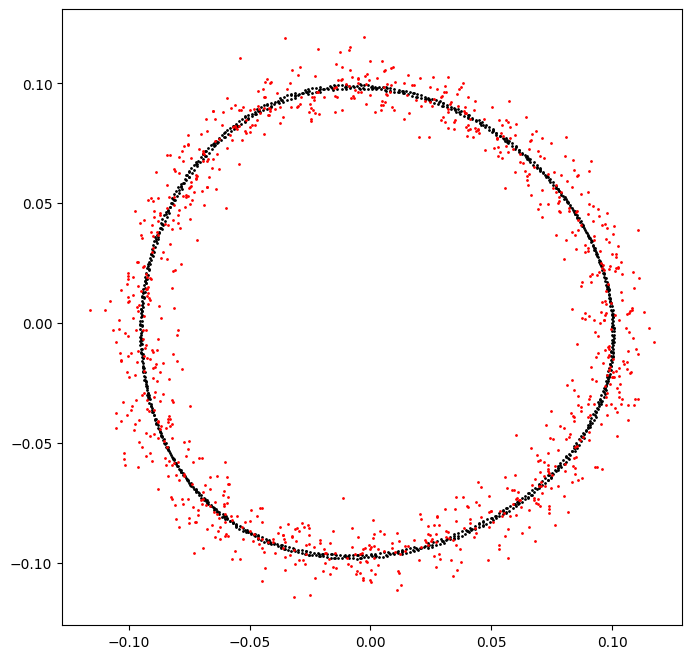

[1.62899526e-07]
[3.89685903e-07]

[1.85436931e-05]
[2.31489836e-06]



In [10]:
# Add noise to the first orbit

# Set signal with noise

n = 0.0075
c = 1024
w = Window.from_cosine(c, 1.0, dtype=torch.float64)
q = qa[:c].clone()
p = pa[:c].clone()
q += n*torch.randn_like(q)
p += n*torch.randn_like(p)
z = q - 1j*p

# Plot orbit with noise

plt.figure(figsize=(8, 8))
plt.scatter(qa[:c], pa[:c], s=1, color='black')
plt.scatter(q, p, s=1, color='red')
plt.show()

# Estimate frequency

t = Data.from_data(w, torch.stack([z]))
f = Frequency(t, f_range=(0.0, 1.0))
t.window_apply()
f('parabola')
t.reset()

print((out[0] - f.candan_get_frequency()).abs().cpu().numpy())
print((out[0] - f.frequency).abs().cpu().numpy())
print()

advance = mod(t.data.angle().diff(), 2*pi)/(2*pi)
window = birkhoff(c - 1)

print((out[0] - advance.mean()).abs().unsqueeze(0).cpu().numpy())
print((out[0] - (advance @ window/window.sum())).abs().cpu().numpy())
print()

In [11]:
# Test instantaneous frequency (Hilbert) with Birkhoff averaging

dht = f.dht(torch.stack([q])[:, :c])
dht = 1/(2.0*pi)*(dht[:, :-1]*dht[:, 1:].conj()).angle()

print((out[0] - dht.mean()).abs().unsqueeze(0).cpu().numpy())
print((out[0] - (dht @ window)/window.sum()).abs().cpu().numpy())
print()

[0.00020099]
[7.07450833e-06]



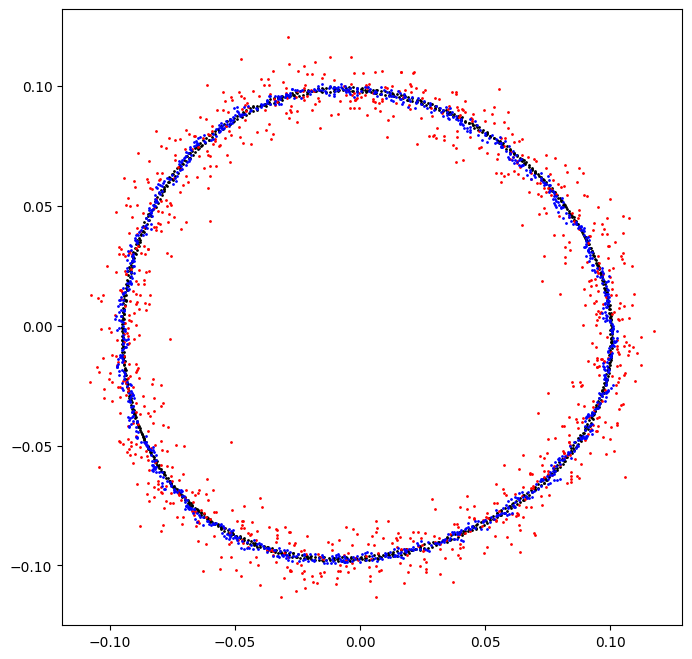

[6.02885673e-07]
[6.16419612e-07]

[2.09920468e-06]
[5.45426852e-07]



In [12]:
# Filter signal (Hankel filter)
# Note, need to filter q and p separatly

# Set signal with noise

n = 0.0075
c = 1024
w = Window.from_cosine(c, 1.0, dtype=torch.float64)
q = qa[:c].clone()
p = pa[:c].clone()
q += n*torch.randn_like(q)
p += n*torch.randn_like(p)

# Filter

from harmonica.filter import Filter
t = Data.from_data(w, torch.stack([q, p]))
flt = Filter(t)
flt.filter_hankel(rank=8)
qf, pf = t.work.clone()
z = qf - 1j*pf

# Plot filtered orbit

plt.figure(figsize=(8, 8))
plt.scatter(qa[:c], pa[:c], s=1, color='black')
plt.scatter(q, p, s=1, color='red')
plt.scatter(qf, pf, s=1, color='blue')
plt.show()

# Estimate frequency

t = Data.from_data(w, torch.stack([z]))
f = Frequency(t, f_range=(0.0, 1.0))
t.window_apply()
f('parabola')
t.reset()

print((out[0] - f.candan_get_frequency()).abs().cpu().numpy())
print((out[0] - f.frequency).abs().cpu().numpy())
print()

advance = mod(t.data.angle().diff(), 2*pi)/(2*pi)
window = birkhoff(c - 1)

print((out[0] - advance.mean()).abs().unsqueeze(0).cpu().numpy())
print((out[0] - (advance @ window/window.sum())).abs().cpu().numpy())
print()

In [13]:
# Test instantaneous frequency (Hilbert) with Birkhoff averaging

dht = f.dht(torch.stack([qf])[:, :c])
dht = 1/(2.0*pi)*(dht[:, :-1]*dht[:, 1:].conj()).angle()

print((out[0] - dht.mean()).abs().unsqueeze(0).cpu().numpy())
print((out[0] - (dht @ window)/window.sum()).abs().cpu().numpy())
print()

[9.86566566e-05]
[1.88634203e-07]

